=== UNSUPERVISED CLUSTERING METRICS ===
K-Means Silhouette Score: 0.460
Hierarchical Silhouette Score: 0.447
K-Means Adjusted Rand Index (ARI vs True Labels): 0.620
Hierarchical ARI vs True Labels: 0.615



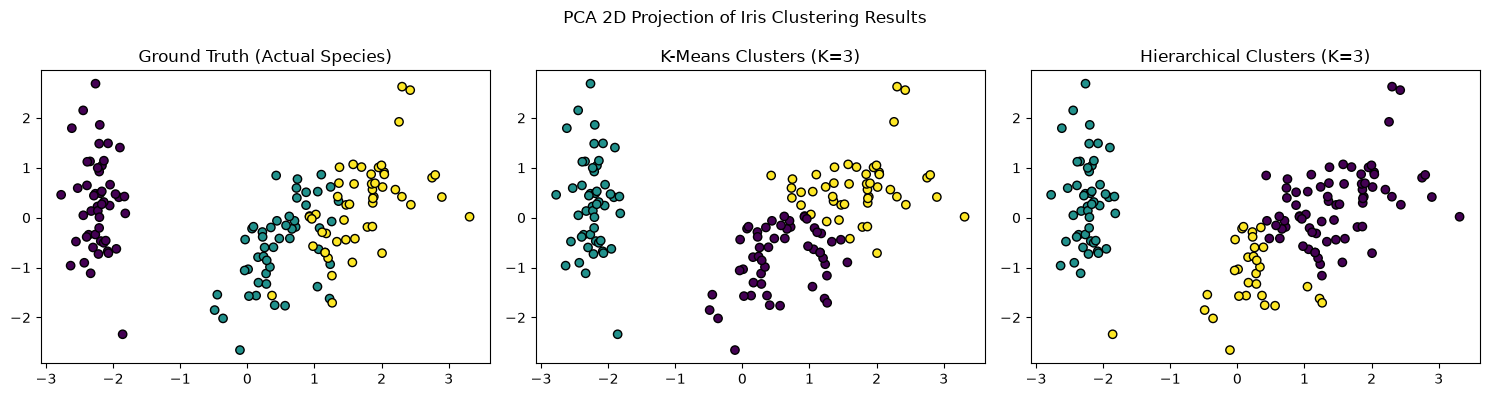

=== SUPERVISED MODEL EVALUATION (Random Forest) ===
Best Parameters: {'criterion': 'entropy', 'max_depth': 2, 'n_estimators': 100}

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Multiclass ROC-AUC Score (OVR): 0.990


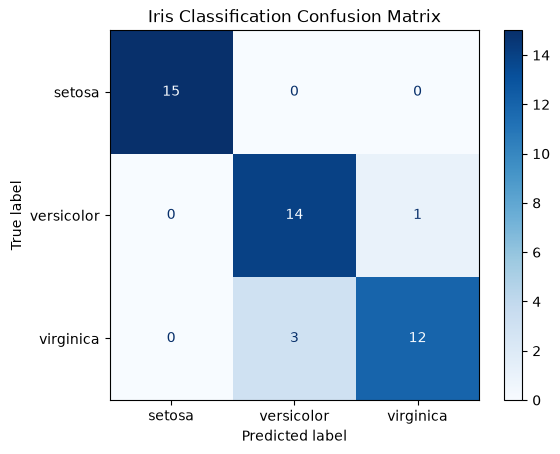

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    classification_report,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# PART 1: CLUSTERING & DIMENSIONALITY REDUCTION
# ==========================================

# 1. Load Iris Data
df = load_iris()
X = df.data
y = df.target
feature_names = df.feature_names
target_names = df.target_names

# 2. Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Dimensionality Reduction (PCA to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. K-Means Clustering (K=3 because Iris has 3 species)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 5. Hierarchical Clustering (K=3)
hc = AgglomerativeClustering(
    n_clusters=3, metric='euclidean', linkage='ward'
)
hc_labels = hc.fit_predict(X_scaled)

# Evaluate Clustering Performance
print('=== UNSUPERVISED CLUSTERING METRICS ===')
print(f'K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}')
print(f'Hierarchical Silhouette Score: {silhouette_score(X_scaled, hc_labels):.3f}')
print(f'K-Means Adjusted Rand Index (ARI vs True Labels): {adjusted_rand_score(y, kmeans_labels):.3f}')
print(f'Hierarchical ARI vs True Labels: {adjusted_rand_score(y, hc_labels):.3f}\n')

# Visualizing PCA and Clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
axes[0].set_title('Ground Truth (Actual Species)')

axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolor='k'
)
axes[1].set_title('K-Means Clusters (K=3)')

axes[2].scatter(
    X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap='viridis', edgecolor='k'
)
axes[2].set_title('Hierarchical Clusters (K=3)')

plt.suptitle('PCA 2D Projection of Iris Clustering Results')
plt.tight_layout()
plt.show()


# PART 2: MODEL EVALUATION & TUNING

# Train-Test Split for Supervised Evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Hyperparameter Tuning using GridSearchCV & Stratified K-Fold CV
param_grid = {
    'n_estimators': [20, 50, 100],
    'max_depth': [2, 3, 5],
    'criterion': ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_probs = best_rf.predict_proba(X_test)

# Report Supervised Results
print('=== SUPERVISED MODEL EVALUATION (Random Forest) ===')
print(f'Best Parameters: {grid_search.best_params_}')
print('\nClassification Report (Precision, Recall, F1-Score):')
print(classification_report(y_test, y_pred, target_names=target_names))

# Multiclass ROC-AUC Score (One-vs-Rest)
roc_auc = roc_auc_score(y_test, y_probs, multi_class='ovr')
print(f'Multiclass ROC-AUC Score (OVR): {roc_auc:.3f}')

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=target_names, cmap='Blues'
)
plt.title('Iris Classification Confusion Matrix')
plt.show()